In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from atlid_functions_mask import *
from matplotlib.lines import Line2D
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import copy
import glob
from matplotlib.ticker import MultipleLocator
from scipy.stats import percentileofscore

In [2]:
# Reading the cloud borders for baseline BA and computing metrics
# ===============================================================
files_cpl_ba = glob.glob('cloud-top-cpl-*[!-ca].csv')
files_atc_ba  = glob.glob('cloud-top-ec-*[!-ca].csv')
files_cth_ba = glob.glob('acth_feb*_old.csv')

files_cpl_ba.sort()
files_atc_ba.sort()
files_cth_ba.sort()

tops_cpl_ba  = np.array([])
tops_ec_ba  = np.array([])
tops_cth_ba  = np.array([])

base_cpl_ba = np.array([])
base_ec_ba  = np.array([])
acth_ba     = pd.DataFrame()

corrs_atc_ba = []
rmse_atc_ba  = []
mae_atc_ba   = []

corrs_cth_ba = []
rmse_cth_ba  = []
mae_cth_ba   = []

for file_cpl, file_ec, file_cth in zip(files_cpl_ba, files_atc_ba, files_cth_ba):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-8:-4] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ba = np.concatenate([tops_cpl_ba, df_interp_cpl_border[var_top]])
    tops_ec_ba  = np.concatenate([tops_ec_ba, df_ec_border[var_top]])
    
    base_cpl_ba = np.concatenate([base_cpl_ba, df_interp_cpl_border[var_base]])
    base_ec_ba  = np.concatenate([base_ec_ba, df_ec_border[var_base]])

    acth_ba = pd.concat([acth_ba, df_acth])

    # Statistics A-TC
    data_atc = pd.concat([df_interp_cpl_border[var_top], df_ec_border[var_top]], axis = 1).dropna()
    data_atc.columns = ['cpl', 'ec']
    corrs_atc_ba.append(data_atc.corr()['cpl']['ec'])
    rmse_atc_ba.append(np.sqrt(mean_squared_error(data_atc['cpl'], data_atc['ec'])))
    mae_atc_ba.append(np.mean(np.abs(data_atc['cpl'] - data_atc['ec'])))

    # Statistics A-CTH
    corrs_cth_ba.append(df_acth.corr()['cpl']['ec'])
    rmse_cth_ba.append(np.sqrt(mean_squared_error(df_acth['cpl'], df_acth['ec'])))
    mae_cth_ba.append(np.mean(np.abs(df_acth['cpl'] - df_acth['ec'])))

In [3]:
# Reading the cloud borders for baseline BD
# =========================================
files_cpl_ca = glob.glob('cloud-top-cpl-*-ca.csv')
files_atc_ca  = glob.glob('cloud-top-ec-*-ca.csv')
files_cth_ca  = glob.glob('acth_feb*_CA.csv')

files_cpl_ca.sort()
files_atc_ca.sort()
files_cth_ca.sort()

tops_cpl_ca  = np.array([])
tops_ec_ca  = np.array([])

base_cpl_ca = np.array([])
base_ec_ca  = np.array([])
acth_ca     = pd.DataFrame()

corrs_atc_ca = []
rmse_atc_ca  = []
mae_atc_ca   = []

corrs_cth_ca = []
rmse_cth_ca  = []
mae_cth_ca   = []

for file_cpl, file_ec, file_cth in zip(files_cpl_ca, files_atc_ca, files_cth_ca):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-11:-7] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ca = np.concatenate([tops_cpl_ca, df_interp_cpl_border[var_top]])
    tops_ec_ca  = np.concatenate([tops_ec_ca, df_ec_border[var_top]])
    
    base_cpl_ca = np.concatenate([base_cpl_ca, df_interp_cpl_border[var_base]])
    base_ec_ca  = np.concatenate([base_ec_ca, df_ec_border[var_base]])

    acth_ca = pd.concat([acth_ca, df_acth])

    # Statistics A-TC
    data_atc = pd.concat([df_interp_cpl_border[var_top], df_ec_border[var_top]], axis = 1).dropna()
    data_atc.columns = ['cpl', 'ec']
    corrs_atc_ca.append(data_atc.corr()['cpl']['ec'])
    rmse_atc_ca.append(np.sqrt(mean_squared_error(data_atc['cpl'], data_atc['ec'])))
    mae_atc_ca.append(np.mean(np.abs(data_atc['cpl'] - data_atc['ec'])))

    # Statistics A-CTH
    corrs_cth_ca.append(df_acth.corr()['cpl']['ec'])
    rmse_cth_ca.append(np.sqrt(mean_squared_error(df_acth['cpl'], df_acth['ec'])))
    mae_cth_ca.append(np.mean(np.abs(df_acth['cpl'] - df_acth['ec'])))

Percentile of A-TC baseline BA below 0.3 km: 76.15
Percentile of A-TC baseline BA below 0.1 km: 37.41


Percentile of A-CTH baseline BA below 0.3 km: 79.69
Percentile of A-CTH baseline BA below 0.1 km: 31.25


Percentile of A-TC baseline BD below 0.3 km: 80.17
Percentile of A-TC baseline BD below 0.1 km: 40.85


Percentile of A-CTH baseline BD below 0.3 km: 85.03
Percentile of A-CTH baseline BD below 0.1 km: 44.03




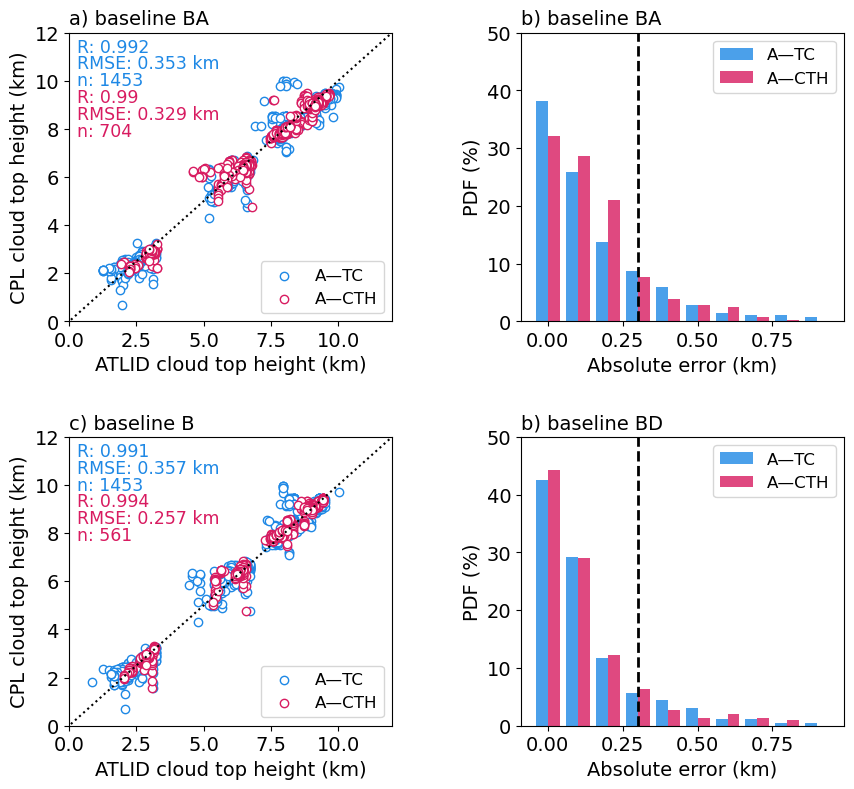

In [5]:
plt.close('all')
fig = plt.figure(figsize = (10,9))
plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.4)
ax1 = fig.add_subplot(221)

tops_real = pd.DataFrame([tops_ec_ba, tops_cpl_ba]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ba.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ba['cpl'], acth_ba['ec']))
counts_acth = len(acth_ba)

ax1.text(.3, 11.2, 'R: ' + str(round(corr_tops[0][1], 3)), fontsize = 12.5, color = '#1E88E5')
ax1.text(.3, 10.5, 'RMSE: ' + str(round(rmse, 3)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax1.text(.3, 9.8, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax1.text(.3, 9.1, 'R: ' + str(round(corr_acth[0][1], 3)), fontsize = 12.5, color = '#D81B60')
ax1.text(.3, 8.4, 'RMSE: ' + str(round(rmse_acth, 3)) + ' km', fontsize = 12.5, color = '#D81B60')
ax1.text(.3, 7.7, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax1.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax1.scatter(tops_ec_ba, tops_cpl_ba, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax1.scatter(acth_ba['ec'], acth_ba['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH')

ax1.set_xlim(0.,12)
ax1.set_ylim(0.,12)

ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

ax1.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax1.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax1.set_title('a) baseline BA', loc = 'left', fontsize = 14)
ax1.legend(loc = 4, fontsize = 12)


ax3 = fig.add_subplot(222)

# Baseline BA
AE_ba = np.abs(tops_cpl_ba - tops_ec_ba)
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data1 = np.sort(AE_ba)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BA below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BA below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ba = np.abs(acth_ba['cpl'] - acth_ba['ec'])
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data2 = np.sort(AE_ba)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BA below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BA below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax3.set_ylim(0, 50)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax3.set_xlabel("Absolute error (km)", fontsize= 14)
ax3.set_ylabel("PDF (%)", fontsize=14)
ax3.set_title('b) baseline BA', loc = 'left', fontsize = 14)

ax2 = fig.add_subplot(223)

tops_real = pd.DataFrame([tops_ec_ca, tops_cpl_ca]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ca.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ca['cpl'], acth_ca['ec']))
counts_acth = len(acth_ca)

ax2.text(.3, 11.2, 'R: ' + str(round(corr_tops[0][1], 3)), fontsize = 12.5, color = '#1E88E5')
ax2.text(.3, 10.5, 'RMSE: ' + str(round(rmse, 3)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax2.text(.3, 9.8, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax2.text(.3, 9.1, 'R: ' + str(round(corr_acth[0][1], 3)), fontsize = 12.5, color = '#D81B60')
ax2.text(.3, 8.4, 'RMSE: ' + str(round(rmse_acth, 3)) + ' km', fontsize = 12.5, color = '#D81B60')
ax2.text(.3, 7.7, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax2.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax2.scatter(tops_ec_ca, tops_cpl_ca, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax2.scatter(acth_ca['ec'], acth_ca['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH')

ax2.set_xlim(0.,12)
ax2.set_ylim(0.,12)

ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax2.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax2.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax2.set_title('c) baseline B', loc = 'left', fontsize = 14)
ax2.legend(loc = 4, fontsize = 12)

ax4 = fig.add_subplot(224)

# Baseline CA
AE_ca = np.abs(tops_cpl_ca - tops_ec_ca)
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data1 = np.sort(AE_ca)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BD below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BD below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ca = np.abs(acth_ca['cpl'] - acth_ca['ec'])
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data2 = np.sort(AE_ca)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BD below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BD below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax4.set_ylim(0, 50)
ax4.tick_params(axis='x', labelsize=14)
ax4.tick_params(axis='y', labelsize=14)
ax4.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax4.set_xlabel("Absolute error (km)", fontsize= 14)
ax4.set_ylabel("PDF (%)", fontsize=14)
ax4.set_title('b) baseline BD', loc = 'left', fontsize = 14)
plt.savefig('Figure11.png', dpi = 350, bbox_inches='tight')

In [6]:
# Case Studies
# Reading the cloud borders for baseline BA
# =========================================
files_cpl_ba = glob.glob('cloud-top-cpl-04.csv')
files_atc_ba  = glob.glob('cloud-top-ec-04.csv')
files_cth_ba = glob.glob('acth_feb04_old.csv')

files_cpl_ba.sort()
files_atc_ba.sort()
files_cth_ba.sort()

tops_cpl_ba  = np.array([])
tops_ec_ba  = np.array([])
tops_cth_ba  = np.array([])

base_cpl_ba = np.array([])
base_ec_ba  = np.array([])
acth_ba     = pd.DataFrame()

for file_cpl, file_ec, file_cth in zip(files_cpl_ba, files_atc_ba, files_cth_ba):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-8:-4] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ba = np.concatenate([tops_cpl_ba, df_interp_cpl_border[var_top]])
    tops_ec_ba  = np.concatenate([tops_ec_ba, df_ec_border[var_top]])
    
    base_cpl_ba = np.concatenate([base_cpl_ba, df_interp_cpl_border[var_base]])
    base_ec_ba  = np.concatenate([base_ec_ba, df_ec_border[var_base]])

    acth_ba = pd.concat([acth_ba, df_acth])

# Reading the cloud borders for baseline BD
# =========================================
files_cpl_ca = glob.glob('cloud-top-cpl-04-ca.csv')
files_atc_ca  = glob.glob('cloud-top-ec-04-ca.csv')
files_cth_ca  = glob.glob('acth_feb04_CA.csv')

files_cpl_ca.sort()
files_atc_ca.sort()
files_cth_ca.sort()

tops_cpl_ca  = np.array([])
tops_ec_ca  = np.array([])

base_cpl_ca = np.array([])
base_ec_ca  = np.array([])
acth_ca     = pd.DataFrame()

for file_cpl, file_ec, file_cth in zip(files_cpl_ca, files_atc_ca, files_cth_ca):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-11:-7] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ca = np.concatenate([tops_cpl_ca, df_interp_cpl_border[var_top]])
    tops_ec_ca  = np.concatenate([tops_ec_ca, df_ec_border[var_top]])
    
    base_cpl_ca = np.concatenate([base_cpl_ca, df_interp_cpl_border[var_base]])
    base_ec_ca  = np.concatenate([base_ec_ca, df_ec_border[var_base]])

    acth_ca = pd.concat([acth_ca, df_acth])

Percentile of A-TC baseline BA below 0.3 km: 88.89
Percentile of A-TC baseline BA below 0.1 km: 52.78


Percentile of A-CTH baseline BA below 0.3 km: 84.21
Percentile of A-CTH baseline BA below 0.1 km: 34.74


Percentile of A-TC baseline BD below 0.3 km: 92.45
Percentile of A-TC baseline BD below 0.1 km: 54.72


Percentile of A-CTH baseline BD below 0.3 km: 86.36
Percentile of A-CTH baseline BD below 0.1 km: 36.36




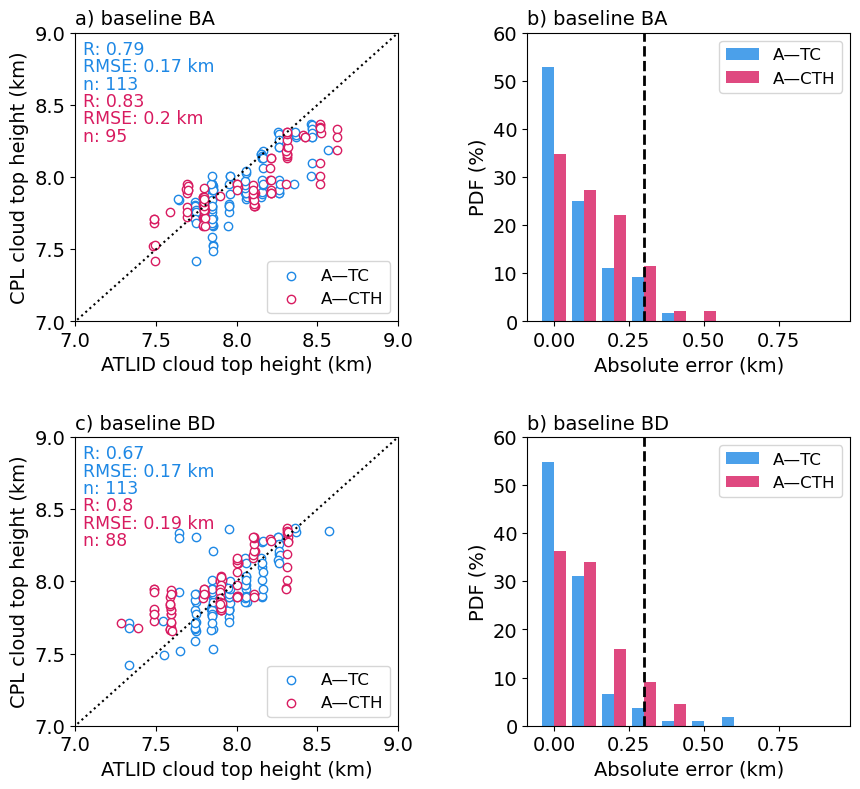

In [8]:
plt.close('all')
fig = plt.figure(figsize = (10,9))
plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.4)
ax1 = fig.add_subplot(221)

tops_real = pd.DataFrame([tops_ec_ba, tops_cpl_ba]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ba.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ba['cpl'], acth_ba['ec']))
counts_acth = len(acth_ba)

ax1.text(7.05, 8.85, 'R: ' + str(round(corr_tops[0][1], 2)), fontsize = 12.5, color = '#1E88E5')
ax1.text(7.05, 8.73, 'RMSE: ' + str(round(rmse, 2)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax1.text(7.05, 8.61, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax1.text(7.05, 8.49, 'R: ' + str(round(corr_acth[0][1], 2)), fontsize = 12.5, color = '#D81B60')
ax1.text(7.05, 8.37, 'RMSE: ' + str(round(rmse_acth, 2)) + ' km', fontsize = 12.5, color = '#D81B60')
ax1.text(7.05, 8.25, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax1.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax1.scatter(tops_ec_ba, tops_cpl_ba, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax1.scatter(acth_ba['ec'], acth_ba['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH')

ax1.set_xlim(7.,9)
ax1.set_ylim(7.,9)

ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

ax1.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax1.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax1.set_title('a) baseline BA', loc = 'left', fontsize = 14)
ax1.legend(loc = 4, fontsize = 12)

ax3 = fig.add_subplot(222)

# Baseline BA
AE_ba = np.abs(tops_cpl_ba - tops_ec_ba)
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data1 = np.sort(AE_ba)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BA below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BA below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ba = np.abs(acth_ba['cpl'] - acth_ba['ec'])
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data2 = np.sort(AE_ba)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BA below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BA below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax3.set_ylim(0, 60)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax3.set_xlabel("Absolute error (km)", fontsize= 14)
ax3.set_ylabel("PDF (%)", fontsize=14)
ax3.set_title('b) baseline BA', loc = 'left', fontsize = 14)

ax2 = fig.add_subplot(223)

tops_real = pd.DataFrame([tops_ec_ca, tops_cpl_ca]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ca.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ca['cpl'], acth_ca['ec']))
counts_acth = len(acth_ca)

ax2.text(7.05, 8.85, 'R: ' + str(round(corr_tops[0][1], 2)), fontsize = 12.5, color = '#1E88E5')
ax2.text(7.05, 8.73, 'RMSE: ' + str(round(rmse, 2)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax2.text(7.05, 8.61, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax2.text(7.05, 8.49, 'R: ' + str(round(corr_acth[0][1], 2)), fontsize = 12.5, color = '#D81B60')
ax2.text(7.05, 8.37, 'RMSE: ' + str(round(rmse_acth, 2)) + ' km', fontsize = 12.5, color = '#D81B60')
ax2.text(7.05, 8.25, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax2.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax2.scatter(tops_ec_ca, tops_cpl_ca, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax2.scatter(acth_ca['ec'], acth_ca['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH')

ax2.set_xlim(7.,9)
ax2.set_ylim(7.,9)

ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax2.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax2.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax2.set_title('c) baseline BD', loc = 'left', fontsize = 14)
ax2.legend(loc = 4, fontsize = 12)

ax4 = fig.add_subplot(224)

# Baseline CA
AE_ca = np.abs(tops_cpl_ca - tops_ec_ca)
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data1 = np.sort(AE_ca)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BD below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BD below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ca = np.abs(acth_ca['cpl'] - acth_ca['ec'])
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data2 = np.sort(AE_ca)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BD below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BD below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax4.set_ylim(0, 60)
ax4.tick_params(axis='x', labelsize=14)
ax4.tick_params(axis='y', labelsize=14)
ax4.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax4.set_xlabel("Absolute error (km)", fontsize= 14)
ax4.set_ylabel("PDF (%)", fontsize=14)
ax4.set_title('b) baseline BD', loc = 'left', fontsize = 14)
plt.savefig('Figure5.png', dpi = 350, bbox_inches='tight')

In [9]:
# Case Studies
# Reading the cloud borders for baseline BA
# =========================================
files_cpl_ba = glob.glob('cloud-top-cpl-07.csv')
files_atc_ba  = glob.glob('cloud-top-ec-07.csv')
files_cth_ba = glob.glob('acth_feb07_old.csv')

files_cpl_ba.sort()
files_atc_ba.sort()
files_cth_ba.sort()

tops_cpl_ba  = np.array([])
tops_ec_ba  = np.array([])
tops_cth_ba  = np.array([])

base_cpl_ba = np.array([])
base_ec_ba  = np.array([])
acth_ba     = pd.DataFrame()

for file_cpl, file_ec, file_cth in zip(files_cpl_ba, files_atc_ba, files_cth_ba):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-8:-4] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ba = np.concatenate([tops_cpl_ba, df_interp_cpl_border[var_top]])
    tops_ec_ba  = np.concatenate([tops_ec_ba, df_ec_border[var_top]])
    
    base_cpl_ba = np.concatenate([base_cpl_ba, df_interp_cpl_border[var_base]])
    base_ec_ba  = np.concatenate([base_ec_ba, df_ec_border[var_base]])

    acth_ba = pd.concat([acth_ba, df_acth])

# Reading the cloud borders for baseline BD
# =========================================
files_cpl_ca = glob.glob('cloud-top-cpl-07-ca.csv')
files_atc_ca  = glob.glob('cloud-top-ec-07-ca.csv')
files_cth_ca  = glob.glob('acth_feb07_CA.csv')

files_cpl_ca.sort()
files_atc_ca.sort()
files_cth_ca.sort()

tops_cpl_ca  = np.array([])
tops_ec_ca  = np.array([])

base_cpl_ca = np.array([])
base_ec_ca  = np.array([])
acth_ca     = pd.DataFrame()

for file_cpl, file_ec, file_cth in zip(files_cpl_ca, files_atc_ca, files_cth_ca):
    
    df_interp_cpl_border = pd.read_csv(file_cpl, index_col = 0)
    df_ec_border         = pd.read_csv(file_ec, index_col = 0)
    df_acth              = pd.read_csv(file_cth, index_col = 0)
    
    if file_cpl[-11:-7] in ['12-1', '12-2', '19-1']:
        var_top  = 'water-top'
        var_base = 'water-base'
    else: 
        var_top  = 'ice-top'
        var_base = 'water-base'

    tops_cpl_ca = np.concatenate([tops_cpl_ca, df_interp_cpl_border[var_top]])
    tops_ec_ca  = np.concatenate([tops_ec_ca, df_ec_border[var_top]])
    
    base_cpl_ca = np.concatenate([base_cpl_ca, df_interp_cpl_border[var_base]])
    base_ec_ca  = np.concatenate([base_ec_ca, df_ec_border[var_base]])

    acth_ca = pd.concat([acth_ca, df_acth])

Percentile of A-TC baseline BA below 0.3 km: 70.22
Percentile of A-TC baseline BA below 0.1 km: 33.33


Percentile of A-CTH baseline BA below 0.3 km: 61.18
Percentile of A-CTH baseline BA below 0.1 km: 25.0


Percentile of A-TC baseline BD below 0.3 km: 65.33
Percentile of A-TC baseline BD below 0.1 km: 27.11


Percentile of A-CTH baseline BD below 0.3 km: 72.64
Percentile of A-CTH baseline BD below 0.1 km: 38.68




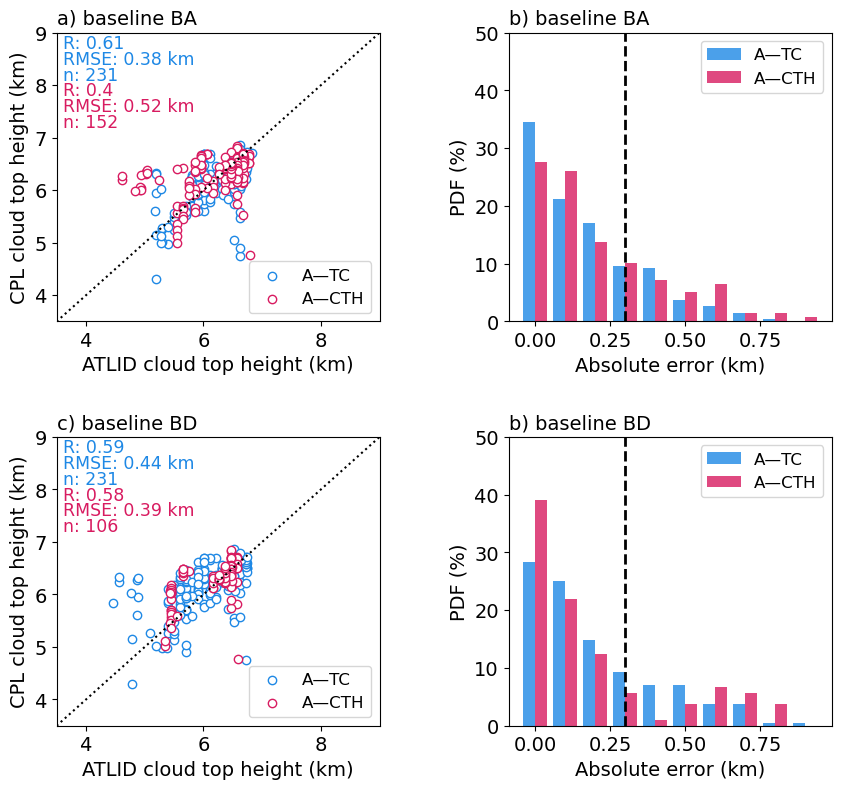

In [10]:
plt.close('all')
fig = plt.figure(figsize = (10,9))
plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.4)
ax1 = fig.add_subplot(221)

tops_real = pd.DataFrame([tops_ec_ba, tops_cpl_ba]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ba.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ba['cpl'], acth_ba['ec']))
counts_acth = len(acth_ba)

ax1.text(3.6, 7.7 + 1, 'R: ' + str(round(corr_tops[0][1], 2)), fontsize = 12.5, color = '#1E88E5')
ax1.text(3.6, 7.4 + 1, 'RMSE: ' + str(round(rmse, 2)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax1.text(3.6, 7.1 + 1, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax1.text(3.6, 6.8 + 1, 'R: ' + str(round(corr_acth[0][1], 2)), fontsize = 12.5, color = '#D81B60')
ax1.text(3.6, 6.5 + 1, 'RMSE: ' + str(round(rmse_acth, 2)) + ' km', fontsize = 12.5, color = '#D81B60')
ax1.text(3.6, 6.2 + 1, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax1.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax1.scatter(tops_ec_ba, tops_cpl_ba, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax1.scatter(acth_ba['ec'], acth_ba['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH') 

ax1.set_xlim(3.5,9)
ax1.set_ylim(3.5,9)

ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)

ax1.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax1.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax1.set_title('a) baseline BA', loc = 'left', fontsize = 14)
ax1.legend(loc = 4, fontsize = 12)

ax3 = fig.add_subplot(222)

# Baseline BA
AE_ba = np.abs(tops_cpl_ba - tops_ec_ba)
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data1 = np.sort(AE_ba)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BA below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BA below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ba = np.abs(acth_ba['cpl'] - acth_ba['ec'])
AE_ba = AE_ba[~np.isnan(AE_ba)]
MAE_ba = np.nanmean(AE_ba)
std_ba = np.nanstd(AE_ba)

data2 = np.sort(AE_ba)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BA below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BA below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ba[np.isfinite(AE_ba)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax3.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax3.set_ylim(0, 50)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax3.set_xlabel("Absolute error (km)", fontsize= 14)
ax3.set_ylabel("PDF (%)", fontsize=14)
ax3.set_title('b) baseline BA', loc = 'left', fontsize = 14)

ax2 = fig.add_subplot(223)

tops_real = pd.DataFrame([tops_ec_ca, tops_cpl_ca]).T.dropna()
tops_real.columns = ['ec', 'cpl']
corr_tops = tops_real.corr().values
rmse = np.sqrt(mean_squared_error(tops_real['cpl'], tops_real['ec']))
counts_fm = len(pd.DataFrame(tops_ec_ba).dropna())

corr_acth = acth_ca.corr().values
rmse_acth = np.sqrt(mean_squared_error(acth_ca['cpl'], acth_ca['ec']))
counts_acth = len(acth_ca)

ax2.text(3.6, 7.7 + 1, 'R: ' + str(round(corr_tops[0][1], 2)), fontsize = 12.5, color = '#1E88E5')
ax2.text(3.6, 7.4 + 1, 'RMSE: ' + str(round(rmse, 2)) + ' km', fontsize = 12.5, color = '#1E88E5')
ax2.text(3.6, 7.1 + 1, 'n: ' + str(counts_fm), fontsize = 12.5, color = '#1E88E5')
ax2.text(3.6, 6.8 + 1, 'R: ' + str(round(corr_acth[0][1], 2)), fontsize = 12.5, color = '#D81B60')
ax2.text(3.6, 6.5 + 1, 'RMSE: ' + str(round(rmse_acth, 2)) + ' km', fontsize = 12.5, color = '#D81B60')
ax2.text(3.6, 6.2 + 1, 'n: ' + str(counts_acth), fontsize = 12.5, color = '#D81B60')

ax2.plot(range(-1,13), range(-1, 13), c = 'k', ls = ':')

ax2.scatter(tops_ec_ca, tops_cpl_ca, edgecolor = '#1E88E5', color = 'w', zorder = 2, label = 'A—TC') 
ax2.scatter(acth_ca['ec'], acth_ca['cpl'], edgecolor = '#D81B60', color = 'w', zorder = 2, label = 'A—CTH')

ax2.set_xlim(3.5,9)
ax2.set_ylim(3.5,9)

ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

ax2.set_ylabel("CPL cloud top height (km)", fontsize= 14)
ax2.set_xlabel("ATLID cloud top height (km)", fontsize=14)
ax2.set_title('c) baseline BD', loc = 'left', fontsize = 14)
ax2.legend(loc = 4, fontsize = 12)

ax4 = fig.add_subplot(224)

# Baseline CA
AE_ca = np.abs(tops_cpl_ca - tops_ec_ca)
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data1 = np.sort(AE_ca)
y = np.arange(1, len(data1) + 1) / len(data1)

print ('Percentile of A-TC baseline BD below 0.3 km: %s' %round( percentileofscore(data1, 0.3) , 2)) 
print ('Percentile of A-TC baseline BD below 0.1 km: %s' %round( percentileofscore(data1, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] - 0.02, freq, color = '#1E88E5', alpha = .8, lw = 2, width = 0.04, label = 'A—TC')

AE_ca = np.abs(acth_ca['cpl'] - acth_ca['ec'])
AE_ca = AE_ca[~np.isnan(AE_ca)]
MAE_ca = np.nanmean(AE_ca)
std_ca = np.nanstd(AE_ca)

data2 = np.sort(AE_ca)
y = np.arange(1, len(data2) + 1) / len(data2)

print ('Percentile of A-CTH baseline BD below 0.3 km: %s' %round( percentileofscore(data2, 0.3) , 2)) 
print ('Percentile of A-CTH baseline BD below 0.1 km: %s' %round( percentileofscore(data2, 0.1) , 2)) 
print ('\n')

freq, bins = np.histogram(AE_ca[np.isfinite(AE_ca)],  bins = 10, range = (0, 1.))
freq = freq*100/np.sum(freq)
binsx = (bins[:-1] + bins[1:])/2
ax4.bar(bins[:-1] + 0.02, freq, color = '#D81B60', alpha = .8, lw = 2, width = 0.04, label = 'A—CTH')

ax4.set_ylim(0, 50)
ax4.tick_params(axis='x', labelsize=14)
ax4.tick_params(axis='y', labelsize=14)
ax4.axvline(x = 0.3, color = 'k', ls = '--', lw = 2.)
plt.legend(fontsize = 12)
ax4.set_xlabel("Absolute error (km)", fontsize= 14)
ax4.set_ylabel("PDF (%)", fontsize=14)
ax4.set_title('b) baseline BD', loc = 'left', fontsize = 14)
plt.savefig('Figure9.png', dpi = 350, bbox_inches='tight')

In [26]:
df_ba = pd.DataFrame({'A-TC': corrs_atc_ba, 'A-CTH': corrs_cth_ba})
df_ba['bl'] = 'BA'
df2_ba = pd.DataFrame({'A-TC': rmse_atc_ba, 'A-CTH': rmse_cth_ba})
df2_ba['bl'] = 'BA'
df3_ba = pd.DataFrame({'A-TC': mae_atc_ba, 'A-CTH': mae_cth_ba})
df3_ba['bl'] = 'BA'

df_ca = pd.DataFrame({'A-TC': corrs_atc_ca, 'A-CTH': corrs_cth_ca})
df_ca['bl'] = 'BD'
df2_ca = pd.DataFrame({'A-TC': rmse_atc_ca, 'A-CTH': rmse_cth_ca})
df2_ca['bl'] = 'BD'
df3_ca = pd.DataFrame({'A-TC': mae_atc_ca, 'A-CTH': mae_cth_ca})
df3_ca['bl'] = 'BD'

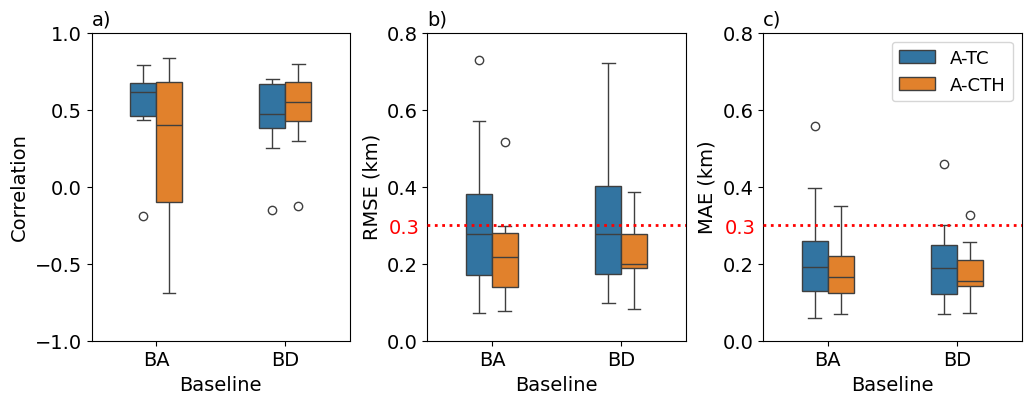

In [34]:
import seaborn as sns

# Plot multiple columns together
fig = plt.figure(figsize = (12,4))
plt.subplots_adjust(wspace=0.3)
ax = fig.add_subplot(131)
dts =  pd.concat([df_ba, df_ca], axis = 0)
dts = dts.melt(id_vars=['bl'], value_vars = ['A-TC', 'A-CTH'], var_name = 'Product', value_name = 'Value',)
sns.boxplot(data = dts, x = 'bl', y = 'Value', hue = 'Product', width=0.4, legend = False)
ax.set_ylabel('Correlation', fontsize = 14)
ax.set_xlabel('Baseline', fontsize = 14)
ax.grid(False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(-1,1)
ax.set_title('a)', fontsize = 14, loc = 'left')


ax = fig.add_subplot(132)
dts2 =  pd.concat([df2_ba, df2_ca], axis = 0)
dts2 = dts2.melt(id_vars=['bl'], value_vars = ['A-TC', 'A-CTH'], var_name = 'Product', value_name = 'Value',)
sns.boxplot(data = dts2, x = 'bl', y = 'Value', hue = 'Product', width=0.4, legend = False)
ax.set_ylabel('RMSE (km)', fontsize = 14)
ax.grid(False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.axhline(y = 0.3, ls = ':', c = 'r', zorder = 3, lw = 2.)
ax.text(-0.8, 0.28, '0.3', fontsize = 14, c = 'r')
ax.set_title('b)', fontsize = 14, loc = 'left')
ax.set_xlabel('Baseline', fontsize = 14)
ax.set_ylim(0,0.8)

ax = fig.add_subplot(133)
dts3 =  pd.concat([df3_ba, df3_ca], axis = 0)
dts3 = dts3.melt(id_vars=['bl'], value_vars = ['A-TC', 'A-CTH'], var_name = 'Product', value_name = 'Value',)
sns.boxplot(data = dts3, x = 'bl', y = 'Value', hue = 'Product', width=0.4)
ax.set_ylabel('MAE (km)', fontsize = 14)
ax.grid(False)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.axhline(y = 0.3, ls = ':', c = 'r', zorder = 3, lw = 2.)
ax.text(-0.8, 0.28, '0.3', fontsize = 14, c = 'r')
ax.set_title('c)', fontsize = 14, loc = 'left')
ax.set_xlabel('Baseline', fontsize = 14)
ax.set_ylim(0,0.8)
ax.legend(fontsize = 13, title_fontsize = 12)
plt.savefig('Figure12.png', dpi = 350, bbox_inches='tight')

In [36]:
df3_ca.median()

/var/folders/t3/7h_vpzzx44bdzqmwnndt__v00000gn/T/ipykernel_42831/3238963531.py:1: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df3_ca.median()


A-TC     0.189265
A-CTH    0.154699
dtype: float64